In [ ]:
import numpy as np
import pandas as pd
import os

cwd = os.getcwd()
path = os.path.join(cwd, "Iris.csv")

In [3]:
df = pd.read_csv(path)
df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [4]:
# remove id
df = df.iloc[:, 1:]
df.head()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


In [ ]:
# label encoder - change class to numeric
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

df["Species"] = encoder.fit_transform(df["Species"])
df.head()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


C:\Users\Tanmay\AppData\Roaming\Python\Python312\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\Tanmay\AppData\Roaming\Python\Python312\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
C:\Users\Tanmay\AppData\Roaming\Python\Python312\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\Tanmay\AppData\Roaming\Python\Python312\site-packages\seaborn\_oldcore.py:1075: Future

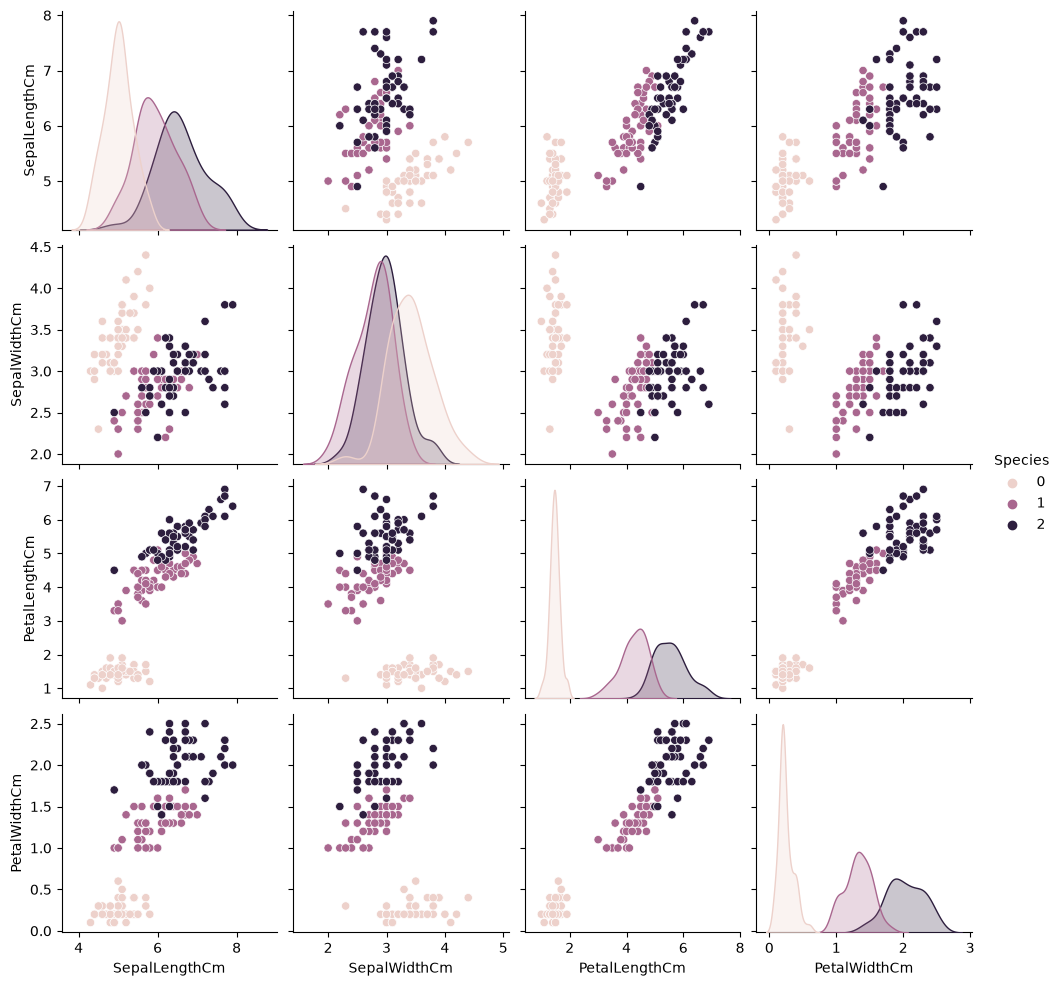

In [ ]:
# to make classification difficult
import seaborn as sns

sns.pairplot(df, hue="Species")

In [ ]:
# keep sepalLeanth and sepalWidth only - to make classification difficult
# also remove the 0 class fowers also , keep only vergnica and versicolor
new_df = df[df["Species"] != 0]
new_df = new_df[["SepalLengthCm", "SepalWidthCm", "Species"]]
new_df

,SepalLengthCm,SepalWidthCm,Species
50,7.0,3.2,1
51,6.4,3.2,1
52,6.9,3.1,1
53,5.5,2.3,1
54,6.5,2.8,1
...,...,...,...
145,6.7,3.0,2
146,6.3,2.5,2
147,6.5,3.0,2
148,6.2,3.4,2


In [23]:
X = df.iloc[:, 0:2]
Y = df.iloc[:, -1]

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score

In [ ]:
clf1 = LogisticRegression()
clf2 = KNeighborsClassifier()
clf3 = RandomForestClassifier()

In [ ]:
estimators = [("lr", clf1), ("knn", clf2), ("rf", clf3)]

In [ ]:
for estimator in estimators:
    x = cross_val_score(estimator[1], X, Y, cv=10, scoring="accuracy")
    print(estimator[0], np.round(np.mean(x), 2))

lr 0.81
knn 0.76
rf 0.73


In [ ]:
# hard voting
from sklearn.ensemble import VotingClassifier

vc = VotingClassifier(estimators=estimators, voting="hard")
x = cross_val_score(vc, X, Y, cv=10, scoring="accuracy")
print(np.round(np.mean(x), 2))

0.77


In [ ]:
# soft voting
from sklearn.ensemble import VotingClassifier

vc = VotingClassifier(estimators=estimators, voting="soft")
x = cross_val_score(vc, X, Y, cv=10, scoring="accuracy")
print(np.round(np.mean(x), 2))

0.77


In [32]:
# finding best weights to these models

maxi = 0
for i in range(1,4):
    for j in range(1,4):
        for k in range(1,4):
            vc = VotingClassifier(estimators=estimators, voting='soft', weights=[i,j,k])
            x = cross_val_score(vc, X, Y, cv=10, scoring="accuracy")
            score =  np.round(np.mean(x), 2)
            print( "for i={}, j={}, k={}".format(i,j,k), score)
            maxi = max(maxi, score)
            
print("max score" , maxi)
            

for i=1, j=1, k=1 0.77
for i=1, j=1, k=2 0.76
for i=1, j=1, k=3 0.73
for i=1, j=2, k=1 0.77
for i=1, j=2, k=2 0.77
for i=1, j=2, k=3 0.75
for i=1, j=3, k=1 0.75
for i=1, j=3, k=2 0.76
for i=1, j=3, k=3 0.77
for i=2, j=1, k=1 0.78
for i=2, j=1, k=2 0.77
for i=2, j=1, k=3 0.75
for i=2, j=2, k=1 0.77
for i=2, j=2, k=2 0.77
for i=2, j=2, k=3 0.76
for i=2, j=3, k=1 0.77
for i=2, j=3, k=2 0.77
for i=2, j=3, k=3 0.77
for i=3, j=1, k=1 0.8
for i=3, j=1, k=2 0.79
for i=3, j=1, k=3 0.77
for i=3, j=2, k=1 0.79
for i=3, j=2, k=2 0.77
for i=3, j=2, k=3 0.77
for i=3, j=3, k=1 0.79
for i=3, j=3, k=2 0.76
for i=3, j=3, k=3 0.77
max score 0.8
